# Building Customer Segmentation using Python

## Step1 : Setup and Initialization

### Step1.1 : Importing Necessary Libraries

In [2]:
!python -m venv venv

In [3]:
!venv\Scripts\activate

In [4]:
!python -m pip install -r requirements.txt


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors as mcolors
from scipy.stats import linregress
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from tabulate import tabulate
from collections import Counter

### Step1.2 : Loading the dataset

In [7]:
import pandas as pd
dataset = pd.read_csv(r"customer_data_internship.csv", encoding='cp1252')
dataset.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Step2 : Initial Data Analysis

### Step2.1 : Dataset Overveiw

In [8]:
import pandas as pd
dataset = pd.read_csv(r"customer_data_internship.csv", encoding='cp1252')
dataset.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Step2.2 : Summary Statistics

In [10]:
# Summary statistics for numerical variables
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [11]:
# Summary statistics for categorical variables
dataset.describe(include='object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/2011 14:41,1114
Country,541909,38,United Kingdom,495478


## Step3 : Data Cleaning and Transformation

### Step3.1 : Handling Missing Values

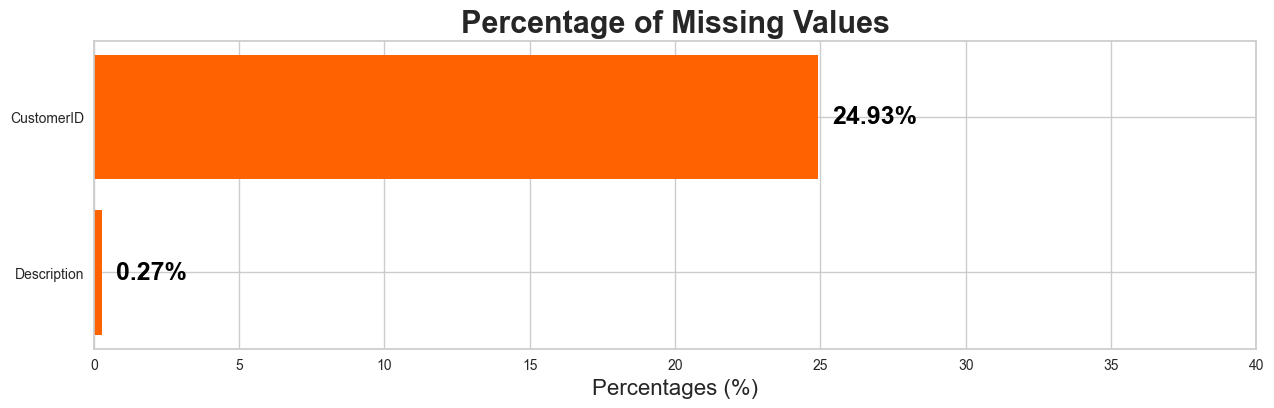

In [12]:
import matplotlib.pyplot as plt
# Calculating the percentage of missing values for each column
missing_data = dataset.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / dataset.shape[0]) * 100
# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)
# Plot the barh chart
fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color='#ff6200')
# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')
# Set x-axis limit
ax.set_xlim([0, 40])
# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

In [13]:
# Extracting rows with missing values in 'CustomerID' or 'Description' columns
dataset[dataset['CustomerID'].isnull() | dataset['Description'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


In [14]:
# Verifying the removal of missing values
dataset.isnull().sum().sum()

np.int64(136534)

### Step3.2 : Handling Duplicates

In [15]:
# Finding duplicate rows (keeping all instances)
duplicate_rows = dataset[dataset.duplicated(keep=False)]
# Sorting the data by certain columns to see the duplicate rows next to each other
duplicate_rows_sorted = duplicate_rows.sort_values(by=['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Quantity'])
# Displaying the first 10 records
duplicate_rows_sorted.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [16]:
# Displaying the number of duplicate rows
print(f"The dataset contains {dataset.duplicated().sum()} duplicate rows that need to be removed.")

# Removing duplicate rows
dataset.drop_duplicates(inplace=True)

The dataset contains 5268 duplicate rows that need to be removed.


In [17]:
# Getting the number of rows in the dataframe
dataset.shape[0]

536641

### Step3.3 : Treating Cancelled Transaction

In [18]:
import numpy as np
# Filter out the rows with InvoiceNo starting with "C" and create a new column indicating the transaction status
dataset['Transaction_Status'] = np.where(dataset['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')
# Analyze the characteristics of these rows (considering the new column)
cancelled_transactions = dataset[dataset['Transaction_Status'] == 'Cancelled']
cancelled_transactions.describe().drop('CustomerID', axis=1)

,Quantity,UnitPrice
count,9251.000000,9251.000000
mean,-29.787050,48.570430
std,1147.997592,667.926393
min,-80995.000000,0.010000
25%,-6.000000,1.450000
50%,-2.000000,2.950000
75%,-1.000000,5.950000
max,-1.000000,38970.000000


In [19]:
# Finding the percentage of cancelled transactions
cancelled_percentage = (cancelled_transactions.shape[0] / dataset.shape[0]) * 100
# Printing the percentage of cancelled transactions
print(f"The percentage of cancelled transactions in the dataset is: {cancelled_percentage:.2f}%")

The percentage of cancelled transactions in the dataset is: 1.72%


### Step3.4 : Correcting Stockcode Anomalies

In [20]:
# Finding the number of unique stock codes
unique_stock_codes = dataset['StockCode'].nunique()
# Printing the number of unique stock codes
print(f"The number of unique stock codes in the dataset is: {unique_stock_codes}")

The number of unique stock codes in the dataset is: 4070


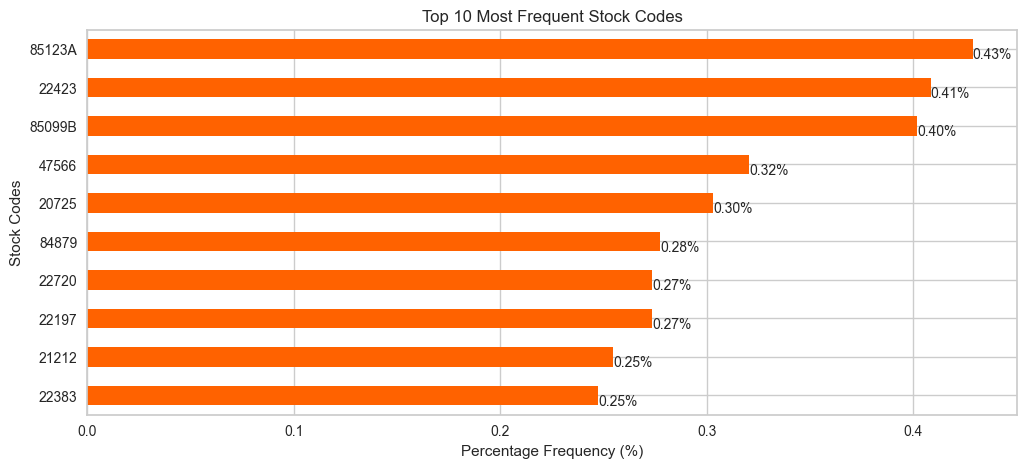

In [21]:
# Finding the top 10 most frequent stock codes
top_10_stock_codes = dataset['StockCode'].value_counts(normalize=True).head(10) * 100
# Plotting the top 10 most frequent stock codes
plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh', color='#ff6200')
# Adding the percentage frequency on the bars
for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%', fontsize=10)
plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency (%)')
plt.ylabel('Stock Codes')
plt.gca().invert_yaxis()
plt.show()

In [22]:
# Finding the number of numeric characters in each unique stock code
unique_stock_codes = dataset['StockCode'].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()
# Printing the value counts for unique stock codes
print("Value counts of numeric character frequencies in unique stock codes:")
print("-"*70)
print(numeric_char_counts_in_unique_codes)

Value counts of numeric character frequencies in unique stock codes:
----------------------------------------------------------------------
5    4037
4      14
0      13
6       5
1       1
Name: count, dtype: int64


In [23]:
# Finding and printing the stock codes with 0 and 1 numeric characters
anomalous_stock_codes = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]
# Printing each stock code on a new line
print("Anomalous stock codes:")
print("-"*22)
for code in anomalous_stock_codes:
    print(code)

Anomalous stock codes:
----------------------
POST
D
C2
DOT
M
BANK CHARGES
S
AMAZONFEE
m
DCGSSBOY
DCGSSGIRL
PADS
B
CRUK


In [24]:
# Calculating the percentage of records with these stock codes
percentage_anomalous = (dataset['StockCode'].isin(anomalous_stock_codes).sum() / len(dataset)) * 100
# Printing the percentage
print(f"The percentage of records with anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with anomalous stock codes in the dataset is: 0.55%


### Step3.5 : Cleaning Description Column

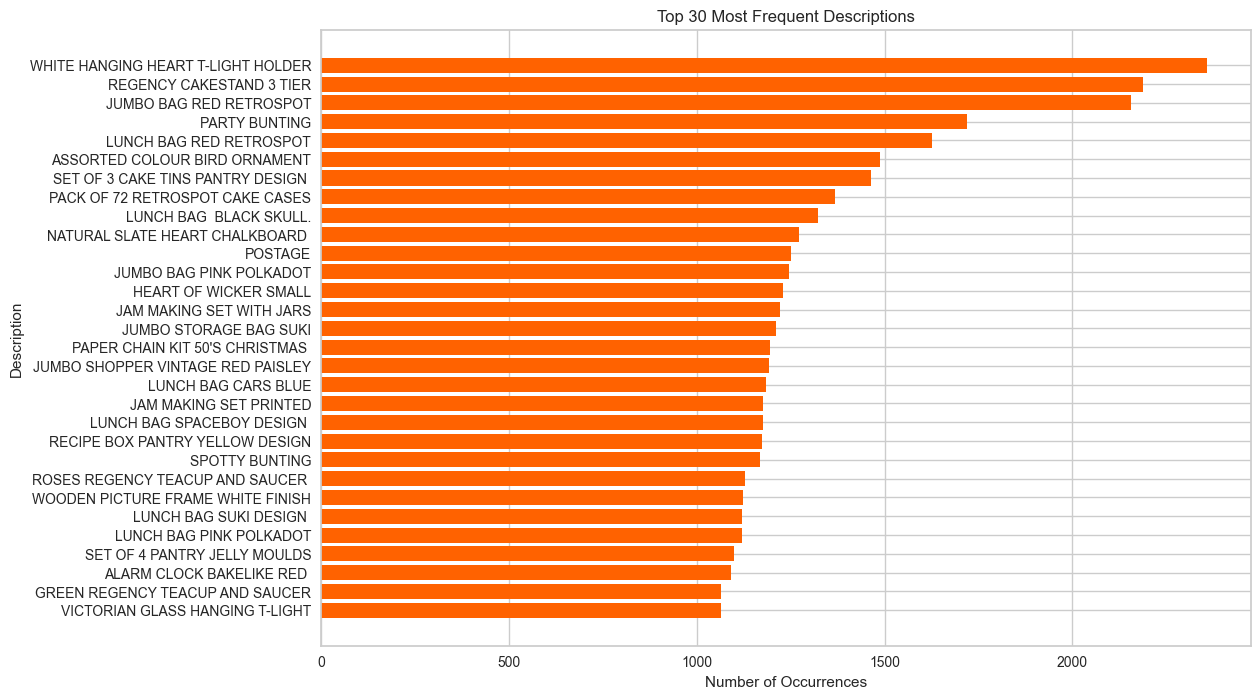

In [25]:
# Calculate the occurrence of each unique description and sort them
description_counts = dataset['Description'].value_counts()
# Get the top 30 descriptions
top_30_descriptions = description_counts[:30]
# Plotting
plt.figure(figsize=(12,8))
plt.barh(top_30_descriptions.index[::-1], top_30_descriptions.values[::-1], color='#ff6200')
# Adding labels and title
plt.xlabel('Number of Occurrences')
plt.ylabel('Description')
plt.title('Top 30 Most Frequent Descriptions')
# Show the plot
plt.show()

In [26]:
# Convert all descriptions to strings
dataset['Description'] = dataset['Description'].astype(str)

# Find unique descriptions containing lowercase characters
lowercase_descriptions = dataset['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]

# Print the unique descriptions containing lowercase characters
print("The unique descriptions containing lowercase characters are:")
print("-"*60)
for desc in lowercase_descriptions:
    print(desc)

The unique descriptions containing lowercase characters are:
------------------------------------------------------------
Discount
BAG 500g SWIRLY MARBLES
nan
POLYESTER FILLER PAD 45x45cm
BAG 125g SWIRLY MARBLES
BAG 250g SWIRLY MARBLES
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
Manual
Dr. Jam's Arouzer Stress Ball
3 TRADITIONAl BISCUIT CUTTERS  SET
Bank Charges
NUMBER TILE COTTAGE GARDEN No
amazon
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
check
damages
Dad's Cab Electronic Meter
NUMBER TILE VINTAGE FONT No 
*Boombox Ipod Classic
faulty
Dotcom sales
amazon sales
*USB Office Mirror Ball
POLYESTER FILLER PAD 30CMx30CM
Dotcomgiftshop Gift Voucher £40.00
Found
Dotcomgiftshop Gift Voucher £50.00
reverse 21/5/10 adjustment
Dotcomgiftshop Gift Voucher £30.00
Dotcomgiftshop Gift Voucher £20.00
mouldy, thrown away.
found
counted
Given away
Dotcom
label mix up
samples/damages
thrown away
incorrec

In [27]:
service_related_descriptions = ["Next Day Carriage", "High Resolution Image"]
# Calculate the percentage of records with service-related descriptions
service_related_percentage = dataset[dataset['Description'].isin(service_related_descriptions)].shape[0] / dataset.shape[0] * 100
# Print the percentage of records with service-related descriptions
print(f"The percentage of records with service-related descriptions in the dataset is: {service_related_percentage:.2f}%")
# Remove rows with service-related information in the description
dataset = dataset[~dataset['Description'].isin(service_related_descriptions)]
# Standardize the text to uppercase to maintain uniformity across the dataset
dataset['Description'] = dataset['Description'].str.upper()

The percentage of records with service-related descriptions in the dataset is: 0.02%


In [28]:
# Getting the number of rows in the dataframe
dataset.shape[0]

536558

### Step3.6 : Treating Zero Unit Prices

In [29]:
dataset['UnitPrice'].describe()

count    536558.000000
mean          4.631060
std          97.240548
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [30]:
dataset[dataset['UnitPrice']==0].describe()[['Quantity']]

,Quantity
count,2510.000000
mean,-53.529880
std,540.739276
min,-9600.000000
25%,-32.750000
50%,-2.000000
75%,3.000000
max,12540.000000


In [31]:
# Removing records with a unit price of zero to avoid potential data entry errors
dataset = dataset[dataset['UnitPrice'] > 0]

### Step3.7 : Outlier Treatment

In [32]:
# Resetting the index of the cleaned dataset
dataset.reset_index(drop=True, inplace=True)

In [33]:
# Getting the number of rows in the dataframe
dataset.shape[0]

534046

## Step4 : Feature Engineering

### Step4.1 : RFM Feature

#### Step4.1.1 : Recency(R)

In [34]:
# Convert InvoiceDate to datetime type
dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'])
# Convert InvoiceDate to datetime and extract only the date
dataset['InvoiceDay'] = dataset['InvoiceDate'].dt.date
# Find the most recent purchase date for each customer
customer_data = dataset.groupby('CustomerID')['InvoiceDay'].max().reset_index()
# Find the most recent date in the entire dataset
most_recent_date = dataset['InvoiceDay'].max()
# Convert InvoiceDay to datetime type before subtraction
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date = pd.to_datetime(most_recent_date)
# Calculate the number of days since the last purchase for each customer
customer_data['Days_Since_Last_Purchase'] = (most_recent_date - customer_data['InvoiceDay']).dt.days
# Remove the InvoiceDay column
customer_data.drop(columns=['InvoiceDay'], inplace=True)
customer_data.head()

,CustomerID,Days_Since_Last_Purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310


#### Step4.1.2 : Frequency(F)

In [35]:
# Calculate the total number of transactions made by each customer
total_transactions = dataset.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns={'InvoiceNo': 'Total_Transactions'}, inplace=True)
# Calculate the total number of products purchased by each customer
total_products_purchased = dataset.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns={'Quantity': 'Total_Products_Purchased'}, inplace=True)
# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_transactions, on='CustomerID')
customer_data = pd.merge(customer_data, total_products_purchased, on='CustomerID')
# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,0
1,12347.0,2,7,2458
2,12348.0,75,4,2341
3,12349.0,18,1,631
4,12350.0,310,1,197


#### Step4.1.3 : Monetary (M)

In [36]:
# Calculate the total spend by each customer
dataset['Total_Spend'] = dataset['UnitPrice'] * dataset['Quantity']
total_spend = dataset.groupby('CustomerID')['Total_Spend'].sum().reset_index()
# Calculate the average transaction value for each customer
average_transaction_value = total_spend.merge(total_transactions, on='CustomerID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']
# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_spend, on='CustomerID')
customer_data = pd.merge(customer_data, average_transaction_value[['CustomerID', 'Average_Transaction_Value']], on='CustomerID')
# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,12346.0,325,2,0,0.00,0.000000
1,12347.0,2,7,2458,4310.00,615.714286
2,12348.0,75,4,2341,1797.24,449.310000
3,12349.0,18,1,631,1757.55,1757.550000
4,12350.0,310,1,197,334.40,334.400000


### Step4.2 : Product Diversity

In [37]:
# Calculate the number of unique products purchased by each customer
unique_products_purchased = dataset.groupby('CustomerID')['StockCode'].nunique().reset_index()
unique_products_purchased.rename(columns={'StockCode': 'Unique_Products_Purchased'}, inplace=True)
# Merge the new feature into the customer_data dataframe
customer_data = pd.merge(customer_data, unique_products_purchased, on='CustomerID')
# Display the first few rows of the customer_data dataframe
customer_data.head()


,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,12346.0,325,2,0,0.00,0.000000,1
1,12347.0,2,7,2458,4310.00,615.714286,103
2,12348.0,75,4,2341,1797.24,449.310000,22
3,12349.0,18,1,631,1757.55,1757.550000,73
4,12350.0,310,1,197,334.40,334.400000,17


In [38]:
customer_data.sample(15)

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
771,13359.0,59,2,159,431.26,215.630000,23
3717,17398.0,114,3,310,653.38,217.793333,30
2998,16402.0,264,2,146,293.45,146.725000,55
1854,14859.0,12,5,669,1352.04,270.408000,47
2255,15397.0,289,1,20,94.00,94.000000,6
1528,14416.0,22,2,326,490.22,245.110000,13
12,12359.0,7,6,1599,6182.98,1030.496667,214
1773,14741.0,11,6,841,1400.34,233.390000,35
1504,14385.0,9,3,159,202.11,67.370000,13
622,13158.0,94,4,784,1201.06,300.265000,59


### Step4.3 : Behavioral Features

In [39]:
# Extract day of week and hour from InvoiceDate
dataset['Day_Of_Week'] = dataset['InvoiceDate'].dt.dayofweek
dataset['Hour'] = dataset['InvoiceDate'].dt.hour
# Calculate the average number of days between consecutive purchases
days_between_purchases = dataset.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases = days_between_purchases.groupby('CustomerID').mean().reset_index()
average_days_between_purchases.rename(columns={'InvoiceDay': 'Average_Days_Between_Purchases'}, inplace=True)
# Find the favorite shopping day of the week
favorite_shopping_day = dataset.groupby(['CustomerID', 'Day_Of_Week']).size().reset_index(name='Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Day_Of_Week']]
# Find the favorite shopping hour of the day
favorite_shopping_hour = dataset.groupby(['CustomerID', 'Hour']).size().reset_index(name='Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Hour']]
# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, average_days_between_purchases, on='CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_day, on='CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_hour, on='CustomerID')
# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14
2,12348.0,75,4,2341,1797.24,449.310000,22,9.433333,3,19
3,12349.0,18,1,631,1757.55,1757.550000,73,0.000000,0,9
4,12350.0,310,1,197,334.40,334.400000,17,0.000000,2,16


### Step4.4 : Geographic Features

In [40]:
dataset['Country'].value_counts(normalize=True).head()

Country
United Kingdom    0.913262
Germany           0.017746
France            0.015991
EIRE              0.015317
Spain             0.004732
Name: proportion, dtype: float64

In [41]:
# Group by CustomerID and Country to get the number of transactions per country for each customer
customer_country = dataset.groupby(['CustomerID', 'Country']).size().reset_index(name='Number_of_Transactions')
# Get the country with the maximum number of transactions for each customer (in case a customer has transactions from multiple countries)
customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending=False).drop_duplicates('CustomerID')
# Create a binary column indicating whether the customer is from the UK or not
customer_main_country['Is_UK'] = customer_main_country['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)
# Merge this data with our customer_data dataframe
customer_data = pd.merge(customer_data, customer_main_country[['CustomerID', 'Is_UK']], on='CustomerID', how='left')
# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0
2,12348.0,75,4,2341,1797.24,449.310000,22,9.433333,3,19,0
3,12349.0,18,1,631,1757.55,1757.550000,73,0.000000,0,9,0
4,12350.0,310,1,197,334.40,334.400000,17,0.000000,2,16,0


In [42]:
# Display feature distribution
customer_data['Is_UK'].value_counts()

Is_UK
1    3871
0     419
Name: count, dtype: int64

### Step4.5 : Cancellation Insights

In [43]:
# modified Block to handle missing values in 'CustomerID' and 'Description' columns

# Make CustomerID consistent
customer_data['CustomerID'] = customer_data['CustomerID'].astype(str)
dataset['CustomerID'] = dataset['CustomerID'].astype(str)

# Build customer-level summaries
total_transactions = (
    dataset.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index(name='Total_Transactions')
)

cancelled_transactions = (
    dataset[dataset['Transaction_Status'] == 'Cancelled']
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index(name='Cancellation_Frequency')
)

# Remove old columns if they already exist
customer_data = customer_data.drop(
    columns=['Total_Transactions', 'Cancellation_Frequency', 'Cancellation_Rate'],
    errors='ignore'
)

# Merge summaries
customer_data = customer_data.merge(total_transactions, on='CustomerID', how='left')
customer_data = customer_data.merge(cancelled_transactions, on='CustomerID', how='left')

# Fill missing values
customer_data['Total_Transactions'] = customer_data['Total_Transactions'].fillna(0)
customer_data['Cancellation_Frequency'] = customer_data['Cancellation_Frequency'].fillna(0)

# Calculate cancellation rate safely
customer_data['Cancellation_Rate'] = (
    customer_data['Cancellation_Frequency'] / customer_data['Total_Transactions']
).fillna(0)

customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions,Cancellation_Frequency,Cancellation_Rate
0,12346.0,325,0,0.00,0.000000,1,0.000000,1,10,1,2,1.0,0.5
1,12347.0,2,2458,4310.00,615.714286,103,2.016575,1,14,0,7,0.0,0.0
2,12348.0,75,2341,1797.24,449.310000,22,9.433333,3,19,0,4,0.0,0.0
3,12349.0,18,631,1757.55,1757.550000,73,0.000000,0,9,0,1,0.0,0.0
4,12350.0,310,197,334.40,334.400000,17,0.000000,2,16,0,1,0.0,0.0


### Step4.6 : Seasonality & Trends

In [44]:
from scipy.stats import linregress
# Extract month and year from InvoiceDate
dataset['Year'] = dataset['InvoiceDate'].dt.year
dataset['Month'] = dataset['InvoiceDate'].dt.month
# Calculate monthly spending for each customer
monthly_spending = dataset.groupby(['CustomerID', 'Year', 'Month'])['Total_Spend'].sum().reset_index()
# Calculate Seasonal Buying Patterns: We are using monthly frequency as a proxy for seasonal buying patterns
seasonal_buying_patterns = monthly_spending.groupby('CustomerID')['Total_Spend'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean': 'Monthly_Spending_Mean', 'std': 'Monthly_Spending_Std'}, inplace=True)
# Replace NaN values in Monthly_Spending_Std with 0, implying no variability for customers with single transaction month
seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)
# Calculate Trends in Spending 
# We are using the slope of the linear trend line fitted to the customer's spending over time as an indicator of spending trends
def calculate_trend(spend_data):
    # If there are more than one data points, we calculate the trend using linear regression
    if len(spend_data) > 1:
        x = np.arange(len(spend_data))
        slope, _, _, _, _ = linregress(x, spend_data)
        return slope
    # If there is only one data point, no trend can be calculated, hence we return 0
    else:
        return 0
# Apply the calculate_trend function to find the spending trend for each customer
spending_trends = monthly_spending.groupby('CustomerID')['Total_Spend'].apply(calculate_trend).reset_index()
spending_trends.rename(columns={'Total_Spend': 'Spending_Trend'}, inplace=True)
# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='CustomerID')
customer_data = pd.merge(customer_data, spending_trends, on='CustomerID')
# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,0,0.00,0.000000,1,0.000000,1,10,1,2,1.0,0.5,0.000000,0.000000,0.000000
1,12347.0,2,2458,4310.00,615.714286,103,2.016575,1,14,0,7,0.0,0.0,615.714286,341.070789,4.486071
2,12348.0,75,2341,1797.24,449.310000,22,9.433333,3,19,0,4,0.0,0.0,449.310000,301.159918,-160.884000
3,12349.0,18,631,1757.55,1757.550000,73,0.000000,0,9,0,1,0.0,0.0,1757.550000,0.000000,0.000000
4,12350.0,310,197,334.40,334.400000,17,0.000000,2,16,0,1,0.0,0.0,334.400000,0.000000,0.000000


In [45]:
# Changing the data type of 'CustomerID' to string as it is a unique identifier and not used in mathematical operations
customer_data['CustomerID'] = customer_data['CustomerID'].astype(str)
# Convert data types of columns to optimal types
customer_data = customer_data.convert_dtypes()


In [46]:
customer_data.head(10)

,CustomerID,Days_Since_Last_Purchase,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,0,0.0,0.0,1,0.0,1,10,1,2,1,0.5,0.0,0.0,0.0
1,12347.0,2,2458,4310.0,615.714286,103,2.016575,1,14,0,7,0,0.0,615.714286,341.070789,4.486071
2,12348.0,75,2341,1797.24,449.31,22,9.433333,3,19,0,4,0,0.0,449.31,301.159918,-160.884
3,12349.0,18,631,1757.55,1757.55,73,0.0,0,9,0,1,0,0.0,1757.55,0.0,0.0
4,12350.0,310,197,334.4,334.4,17,0.0,2,16,0,1,0,0.0,334.4,0.0,0.0
5,12352.0,36,470,1545.41,140.491818,59,2.765957,1,14,0,11,3,0.272727,386.3525,164.216299,37.351
6,12353.0,204,20,89.0,89.0,4,0.0,3,17,0,1,0,0.0,89.0,0.0,0.0
7,12354.0,232,530,1079.4,1079.4,58,0.0,3,13,0,1,0,0.0,1079.4,0.0,0.0
8,12355.0,214,240,459.4,459.4,13,0.0,0,13,0,1,0,0.0,459.4,0.0,0.0
9,12356.0,22,1591,2811.43,937.143333,53,5.224138,1,9,0,3,0,0.0,937.143333,1174.89425,-1106.635


In [47]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4290 entries, 0 to 4289
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      4290 non-null   string 
 1   Days_Since_Last_Purchase        4290 non-null   Int64  
 2   Total_Products_Purchased        4290 non-null   Int64  
 3   Total_Spend                     4290 non-null   Float64
 4   Average_Transaction_Value       4290 non-null   Float64
 5   Unique_Products_Purchased       4290 non-null   Int64  
 6   Average_Days_Between_Purchases  4290 non-null   Float64
 7   Day_Of_Week                     4290 non-null   Int32  
 8   Hour                            4290 non-null   Int32  
 9   Is_UK                           4290 non-null   Int64  
 10  Total_Transactions              4290 non-null   Int64  
 11  Cancellation_Frequency          4290 non-null   Int64  
 12  Cancellation_Rate               42

## Step5 : Outlier Detection and Treating

In [48]:
# Modified block to handle outlier detection and removal using Isolation Forest

from sklearn.ensemble import IsolationForest

# Keep only numeric columns except the ID column
X = customer_data.select_dtypes(include=['number']).copy()

# Replace missing values
X = X.fillna(0)

# Fit IsolationForest
model = IsolationForest(contamination=0.05, random_state=0)
outlier_labels = model.fit_predict(X)

# Store results back in customer_data
customer_data['Outlier_Scores'] = outlier_labels
customer_data['Is_Outlier'] = (customer_data['Outlier_Scores'] == -1).astype(int)

customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Outlier_Scores,Is_Outlier
0,12346.0,325,0,0.0,0.0,1,0.0,1,10,1,2,1,0.5,0.0,0.0,0.0,1,0
1,12347.0,2,2458,4310.0,615.714286,103,2.016575,1,14,0,7,0,0.0,615.714286,341.070789,4.486071,1,0
2,12348.0,75,2341,1797.24,449.31,22,9.433333,3,19,0,4,0,0.0,449.31,301.159918,-160.884,1,0
3,12349.0,18,631,1757.55,1757.55,73,0.0,0,9,0,1,0,0.0,1757.55,0.0,0.0,-1,1
4,12350.0,310,197,334.4,334.4,17,0.0,2,16,0,1,0,0.0,334.4,0.0,0.0,1,0


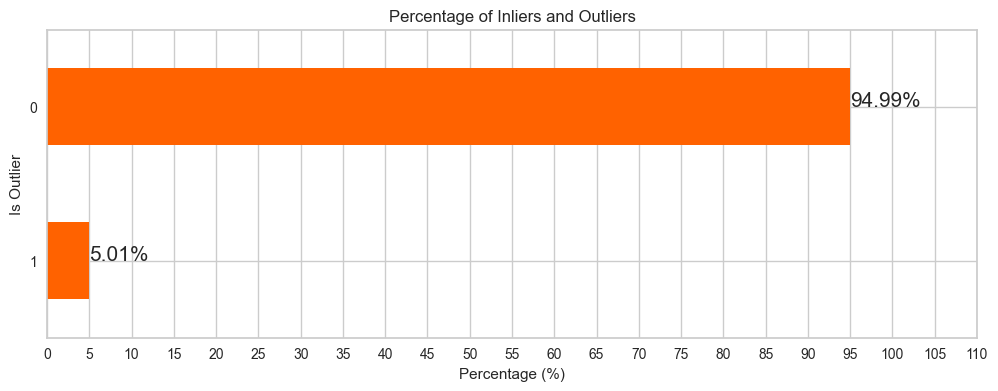

In [49]:
# Calculate the percentage of inliers and outliers
outlier_percentage = customer_data['Is_Outlier'].value_counts(normalize=True) * 100
# Plotting the percentage of inliers and outliers
plt.figure(figsize=(12, 4))
outlier_percentage.plot(kind='barh', color='#ff6200')
# Adding the percentage labels on the bars
for index, value in enumerate(outlier_percentage):
    plt.text(value, index, f'{value:.2f}%', fontsize=15)
plt.title('Percentage of Inliers and Outliers')
plt.xticks(ticks=np.arange(0, 115, 5))
plt.xlabel('Percentage (%)')
plt.ylabel('Is Outlier')
plt.gca().invert_yaxis()
plt.show()

In [50]:
# Separate the outliers for analysis
outliers_data = customer_data[customer_data['Is_Outlier'] == 1]
# Remove the outliers from the main dataset
customer_data_cleaned = customer_data[customer_data['Is_Outlier'] == 0]
# Drop the 'Outlier_Scores' and 'Is_Outlier' columns
customer_data_cleaned = customer_data_cleaned.drop(columns=['Outlier_Scores', 'Is_Outlier'])
# Reset the index of the cleaned data
customer_data_cleaned.reset_index(drop=True, inplace=True)

In [51]:
# Getting the number of rows in the cleaned customer dataset
customer_data_cleaned.shape[0]

4075

## Step6 : Correlation Analysis

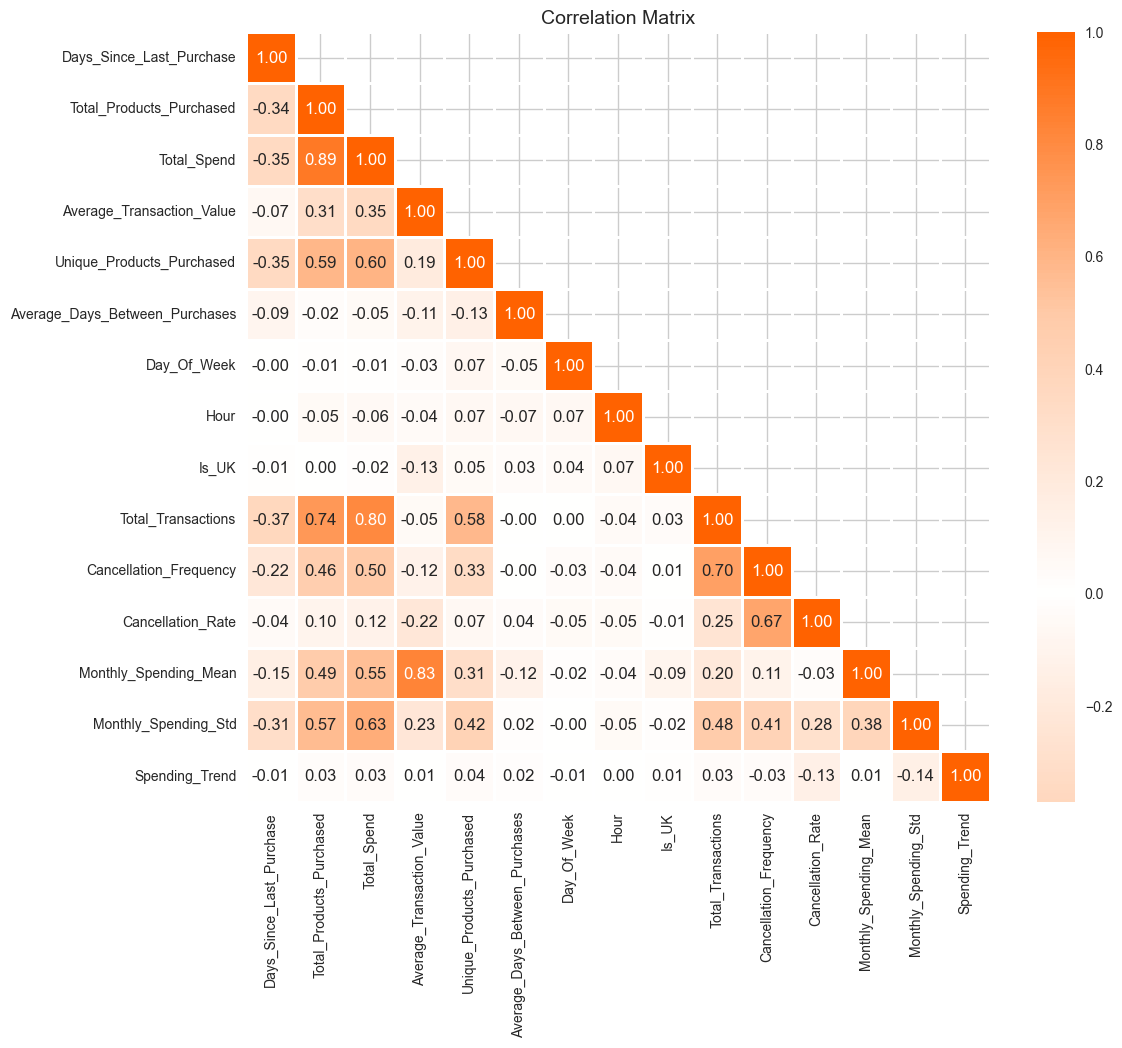

In [52]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
# Reset background style
sns.set_style('whitegrid')
# Calculate the correlation matrix excluding the 'CustomerID' column
corr = customer_data_cleaned.drop(columns=['CustomerID']).corr()
# Define a custom colormap
colors = ['#ff6200', '#ffcaa8', 'white', '#ffcaa8', '#ff6200']
my_cmap = LinearSegmentedColormap.from_list('custom_map', colors, N=256)
# Create a mask to only show the lower triangle of the matrix (since it's mirrored around its 
# top-left to bottom-right diagonal)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True
# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap=my_cmap, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

## Step7 : Feature Scaling

In [53]:
from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler = StandardScaler()
# List of columns that don't need to be scaled
columns_to_exclude = ['CustomerID', 'Is_UK', 'Day_Of_Week']
# List of columns that need to be scaled
columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)
# Copy the cleaned dataset
customer_data_scaled = customer_data_cleaned.copy()
# Applying the scaler to the necessary columns in the dataset
customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])
# Display the first few rows of the scaled data
customer_data_scaled.head()

,CustomerID,Days_Since_Last_Purchase,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,2.365283,-0.763868,-0.794374,-1.359029,-0.902174,-0.313128,1,-1.083097,1,-0.481395,0.302239,2.315476,-1.302618,-0.733299,0.086985
1,12347.0,-0.900527,1.985875,2.205143,1.609731,0.781935,-0.125034,1,0.653865,0,0.609763,-0.526579,-0.609594,0.963128,1.287699,0.114119
2,12348.0,-0.162434,1.854989,0.456404,0.807388,-0.555446,0.566755,3,2.825067,0,-0.044932,-0.526579,-0.609594,0.350782,1.051209,-0.886091
3,12350.0,2.213620,-0.543485,-0.561650,0.253331,-0.638000,-0.313128,2,1.522346,0,-0.699626,-0.526579,-0.609594,-0.072071,-0.733299,0.086985
4,12352.0,-0.556758,-0.238083,0.281144,-0.681626,0.055456,-0.055136,1,0.653865,0,1.482690,1.959875,0.985899,0.119107,0.239757,0.312896


## Step8 : Dimensionality Reduction

In [54]:
#Modified block to handle PCA and determine the optimal number of components

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Do NOT set CustomerID as index again if it is already the index
X = customer_data_scaled.select_dtypes(include=['number']).copy()

# Fill missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Apply PCA
pca = PCA().fit(X_imputed)

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Optimal k
optimal_k = 6
print(customer_data_scaled.columns)
print(customer_data_scaled.index.name)


Index(['CustomerID', 'Days_Since_Last_Purchase', 'Total_Products_Purchased',
       'Total_Spend', 'Average_Transaction_Value', 'Unique_Products_Purchased',
       'Average_Days_Between_Purchases', 'Day_Of_Week', 'Hour', 'Is_UK',
       'Total_Transactions', 'Cancellation_Frequency', 'Cancellation_Rate',
       'Monthly_Spending_Mean', 'Monthly_Spending_Std', 'Spending_Trend'],
      dtype='object')
None


In [55]:
#modified block to handle PCA and determine the optimal number of components

pca = PCA(n_components=6)
customer_data_pca = pca.fit_transform(X_imputed)
customer_data_pca = pd.DataFrame(customer_data_pca, columns=[f'PC{i+1}' for i in range(6)])
customer_data_pca.index = customer_data_scaled.index
print(customer_data_scaled.index.name)
print(customer_data_scaled.columns)


None
Index(['CustomerID', 'Days_Since_Last_Purchase', 'Total_Products_Purchased',
       'Total_Spend', 'Average_Transaction_Value', 'Unique_Products_Purchased',
       'Average_Days_Between_Purchases', 'Day_Of_Week', 'Hour', 'Is_UK',
       'Total_Transactions', 'Cancellation_Frequency', 'Cancellation_Rate',
       'Monthly_Spending_Mean', 'Monthly_Spending_Std', 'Spending_Trend'],
      dtype='object')


In [56]:
# Displaying the resulting dataframe based on the PCs
customer_data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.022935,-1.782163,-2.375625,-1.568828,-0.399677,1.956386
1,3.210005,-1.396698,2.050627,0.670762,-0.120055,-0.795033
2,1.055308,0.592052,1.106353,0.127777,-0.810930,-2.422042
3,-1.930313,-0.497658,0.867019,-0.271549,-1.485977,0.152343
4,1.484570,-1.571273,-1.833046,0.173240,-0.717305,0.143969


In [63]:
# Modified block to handle PCA and determine the optimal number of components

def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color: #ffeacc' if i in top3 else '' for i in column.index]

# Use the same feature set that was used for PCA
feature_names = X.columns  # or the numeric columns used in PCA

pc_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_names
)

pc_df.style.apply(highlight_top3, axis=0)

,PC1,PC2,PC3,PC4,PC5,PC6
Days_Since_Last_Purchase,-0.218737,-0.010640,0.041215,-0.310086,-0.209996,0.404389
Total_Products_Purchased,0.414532,0.005551,0.061642,0.111685,0.028775,0.027995
Total_Spend,0.435687,0.006890,0.070424,0.075809,0.021160,0.051791
Average_Transaction_Value,0.163660,-0.009821,0.576315,-0.241494,0.060349,0.025504
Unique_Products_Purchased,0.331644,0.060492,0.030370,0.234004,-0.192199,-0.077747
Average_Days_Between_Purchases,-0.026531,-0.038555,-0.139303,0.135602,0.725274,-0.299877
Day_Of_Week,-0.016071,0.994288,-0.028377,-0.053630,0.067558,0.037986
Hour,-0.025758,0.057476,0.007840,0.215374,-0.599924,-0.521273
Is_UK,-0.002129,0.006979,-0.018045,0.025724,-0.008660,-0.015752
Total_Transactions,0.390496,0.009204,-0.223431,0.192550,-0.028217,0.067781


## Step9 : K-Means Clustering

### Step9.1 : Determining the optimal number of clusters

#### Step9.1.1 : Elbow Method

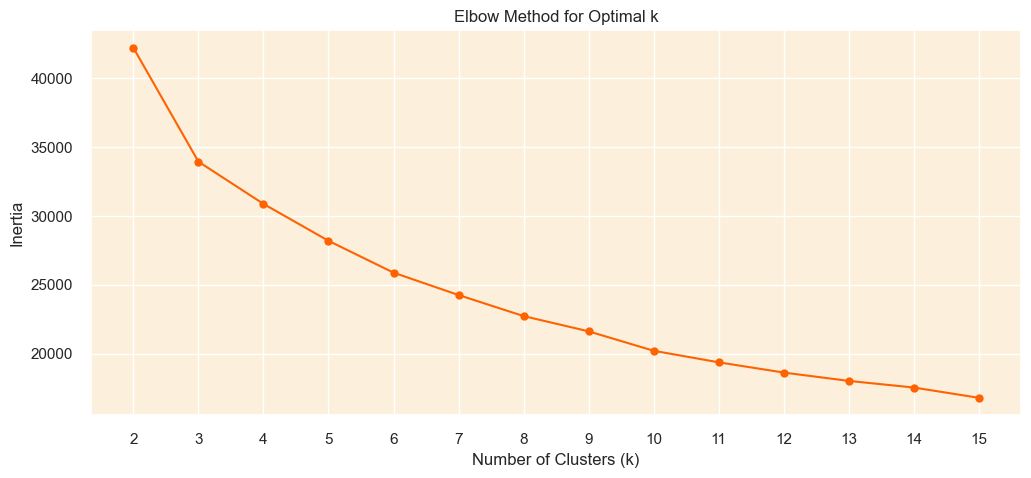

In [64]:
# Modified Block to handle missing values in 'CustomerID' and 'Description' columns

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

# Keep only numeric columns
X = customer_data_scaled.select_dtypes(include=['number']).copy()

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# PCA with 6 components
pca = PCA(n_components=6)
customer_data_pca = pca.fit_transform(X_imputed)

# Create PCA dataframe
customer_data_pca = pd.DataFrame(
    customer_data_pca,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=customer_data_scaled.index
)

# Elbow method manually
inertias = []
k_range = range(2, 16)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=0)
    km.fit(customer_data_pca)
    inertias.append(km.inertia_)

# Plot
sns.set(style='darkgrid', rc={'axes.facecolor': '#fcf0dc'})
plt.figure(figsize=(12, 5))
plt.plot(list(k_range), inertias, marker='o', color='#ff6200')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

#### Step9.1.2 : Silhouette Method

In [65]:
# Modified block to handle outlier detection and removal using Isolation Forest

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

def silhouette_analysis(df, start_k, stop_k, figsize=(15, 16)):
    """
    Perform silhouette analysis for a range of k values and visualize the results.
    """
    sns.set(style='darkgrid', rc={'axes.facecolor': '#fcf0dc'})
    sns.set_palette(['darkorange'])

    n_k = stop_k - start_k + 1
    fig = plt.figure(figsize=figsize)
    grid = gridspec.GridSpec(n_k + 1, 2, figure=fig)

    # Top plot: average silhouette scores
    ax0 = fig.add_subplot(grid[0, :])
    silhouette_scores = []

    for k in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=0)
        labels = km.fit_predict(df)
        score = silhouette_score(df, labels)
        silhouette_scores.append(score)

    best_k = start_k + int(np.argmax(silhouette_scores))

    ax0.plot(range(start_k, stop_k + 1), silhouette_scores, marker='o')
    ax0.set_xticks(list(range(start_k, stop_k + 1)))
    ax0.set_xlabel('Number of clusters (k)')
    ax0.set_ylabel('Silhouette score')
    ax0.set_title('Average Silhouette Score for Different k Values', fontsize=15)

    ax0.text(
        0.02, 0.05,
        f'The k value with the highest Silhouette score is: {best_k}',
        fontsize=12,
        transform=ax0.transAxes,
        bbox=dict(facecolor='#fcc36d', edgecolor='#ff6200', boxstyle='round,pad=0.5')
    )

    # Lower plots: silhouette distribution for each k
    for idx, k in enumerate(range(start_k, stop_k + 1)):
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=0)
        labels = km.fit_predict(df)
        sample_scores = silhouette_samples(df, labels)

        ax = fig.add_subplot(grid[idx + 1, idx % 2])

        y_lower = 10
        for cluster_id in range(k):
            cluster_vals = sample_scores[labels == cluster_id]
            cluster_vals.sort()
            size = len(cluster_vals)
            y_upper = y_lower + size

            ax.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                cluster_vals,
                alpha=0.7
            )
            ax.text(-0.05, y_lower + 0.5 * size, str(cluster_id))
            y_lower = y_upper + 10

        ax.set_title(f'Silhouette Plot for {k} Clusters', fontsize=13)
        ax.set_xlabel('Silhouette coefficient values')
        ax.set_ylabel('Cluster label')
        ax.axvline(x=sample_scores.mean(), color='red', linestyle='--')

    plt.tight_layout()
    plt.show() # silhouette_analysis(customer_data_pca, 3, 12, figsize=(20, 50)) run the silhouette analysis for k values from 3 to 12 in the coming cell
    
print(customer_data_pca.shape)
print(customer_data_pca.head())
    

(4075, 6)
        PC1       PC2       PC3       PC4       PC5       PC6
0 -2.022935 -1.782163 -2.375625 -1.568828 -0.399677  1.956386
1  3.210005 -1.396698  2.050627  0.670762 -0.120055 -0.795033
2  1.055308  0.592052  1.106353  0.127777 -0.810930 -2.422042
3 -1.930313 -0.497658  0.867019 -0.271549 -1.485977  0.152343
4  1.484570 -1.571273 -1.833046  0.173240 -0.717305  0.143969


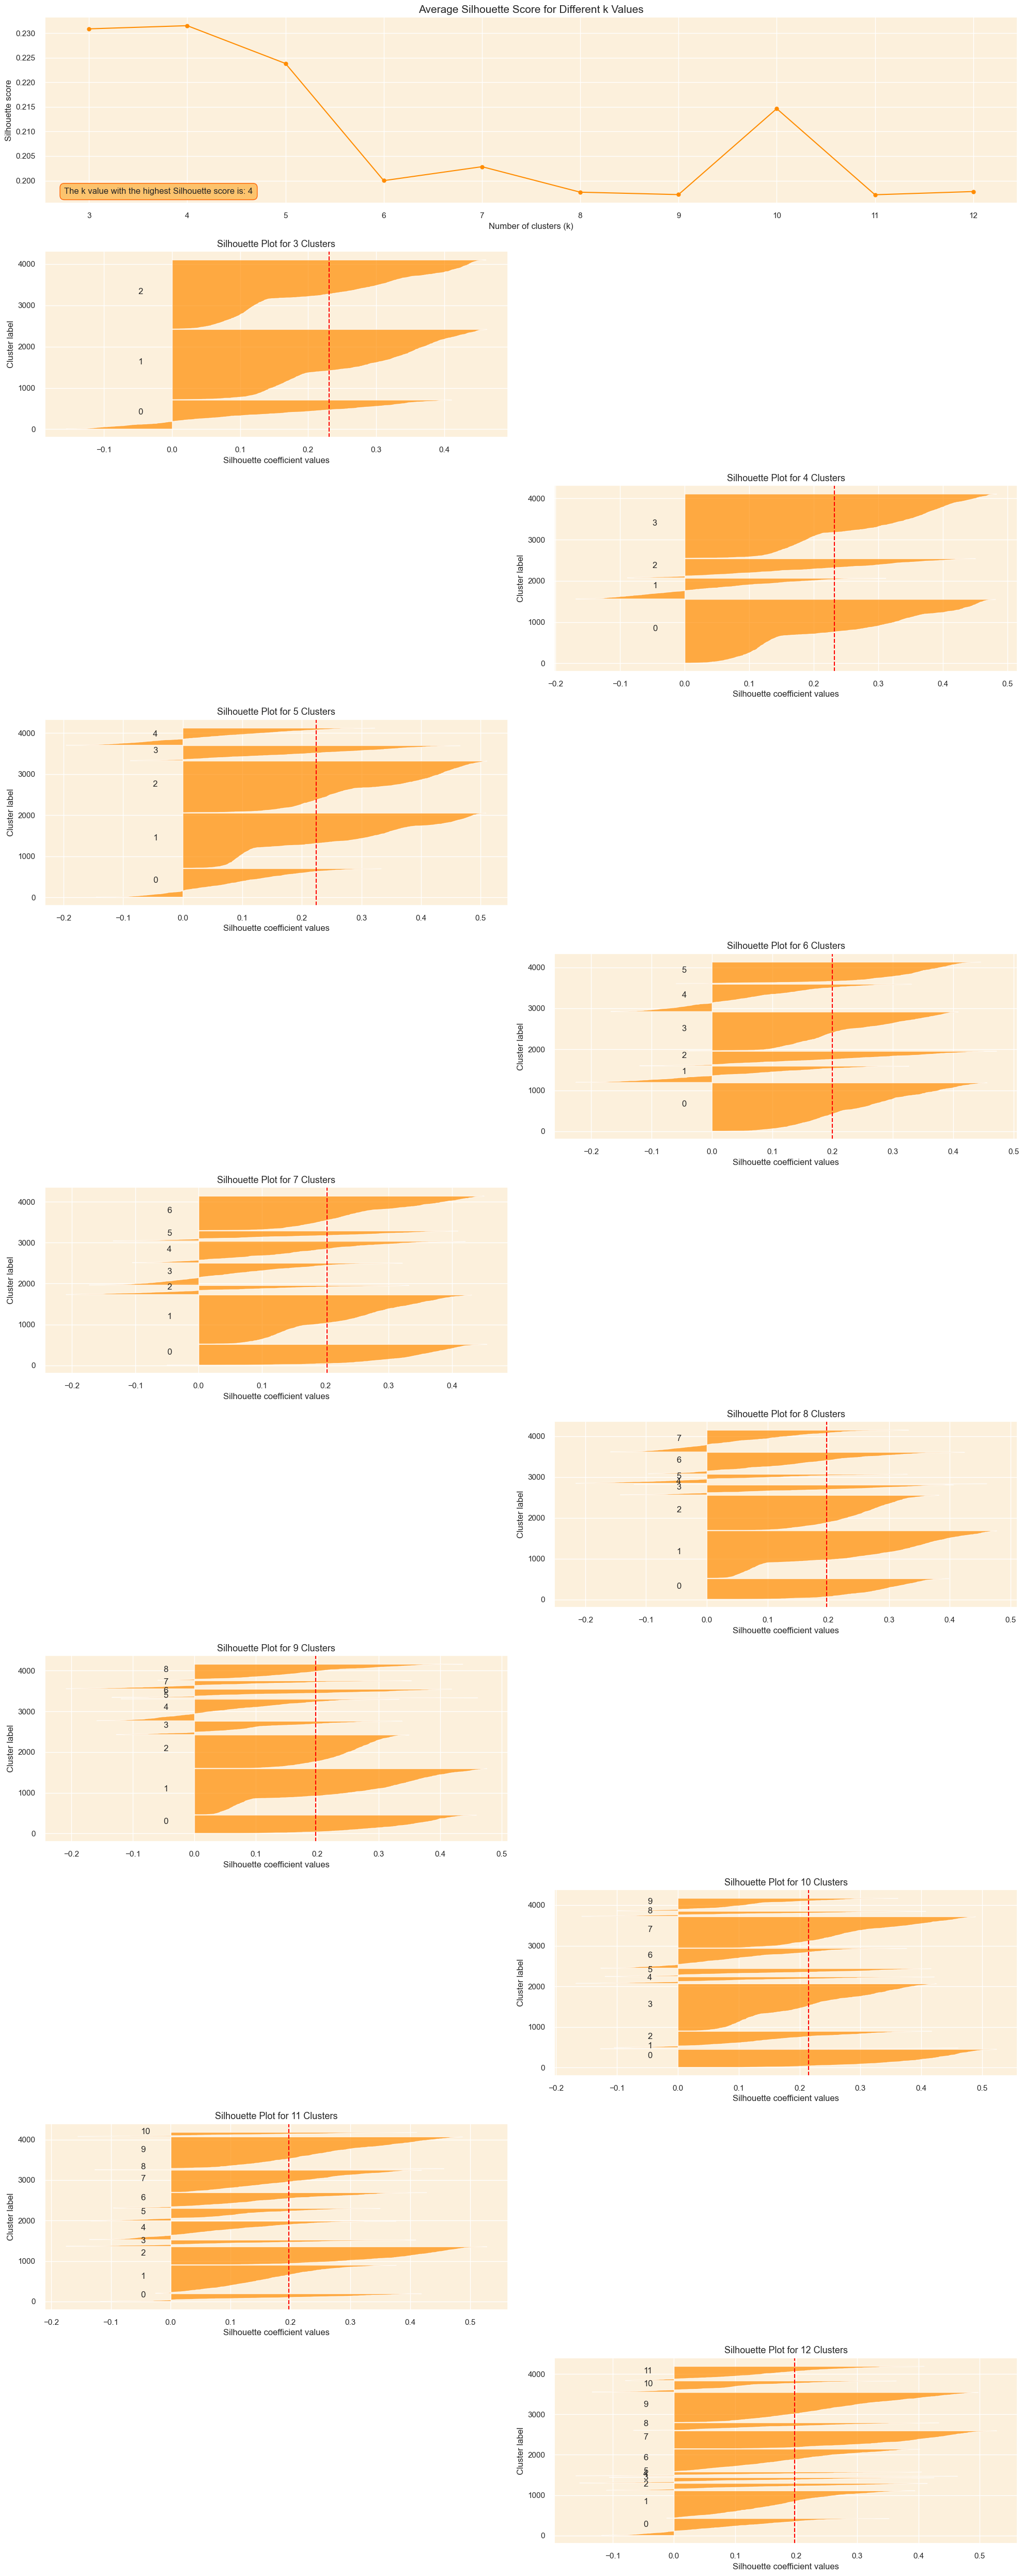

In [66]:
silhouette_analysis(customer_data_pca, 3, 12, figsize=(20, 50))

### Step9.2 : Clustering Model - K-Means

In [67]:
from collections import Counter
# Apply KMeans clustering using the optimal k
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=0)
kmeans.fit(customer_data_pca)
# Get the frequency of each cluster
cluster_frequencies = Counter(kmeans.labels_)
# Create a mapping from old labels to new labels based on frequency
label_mapping = {label: new_label for new_label, (label, _) in 
                 enumerate(cluster_frequencies.most_common())}
# Reverse the mapping to assign labels as per your criteria
label_mapping = {v: k for k, v in {2: 1, 1: 0, 0: 2}.items()}
# Apply the mapping to get the new labels
new_labels = np.array([label_mapping[label] for label in kmeans.labels_])
# Append the new cluster labels back to the original dataset
customer_data_cleaned['cluster'] = new_labels
# Append the new cluster labels to the PCA version of the dataset
customer_data_pca['cluster'] = new_labels

In [68]:
# Display the first few rows of the original dataframe
customer_data_cleaned.head()

,CustomerID,Days_Since_Last_Purchase,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,cluster
0,12346.0,325,0,0.0,0.0,1,0.0,1,10,1,2,1,0.5,0.0,0.0,0.0,2
1,12347.0,2,2458,4310.0,615.714286,103,2.016575,1,14,0,7,0,0.0,615.714286,341.070789,4.486071,1
2,12348.0,75,2341,1797.24,449.31,22,9.433333,3,19,0,4,0,0.0,449.31,301.159918,-160.884,0
3,12350.0,310,197,334.4,334.4,17,0.0,2,16,0,1,0,0.0,334.4,0.0,0.0,2
4,12352.0,36,470,1545.41,140.491818,59,2.765957,1,14,0,11,3,0.272727,386.3525,164.216299,37.351,2


## Step10 : Clustering Evaluation

### Step10.1 : 3D Visualization of Top Principal Components

In [69]:
# Setting up the color scheme for the clusters (RGB order)
colors = ['#e8000b', '#1ac938', '#023eff']

In [70]:
# Modified Block to handle missing values in 'CustomerID' and 'Description' columns

import plotly.graph_objects as go

cluster_0 = customer_data_pca[customer_data_pca['cluster'] == 0]
cluster_1 = customer_data_pca[customer_data_pca['cluster'] == 1]
cluster_2 = customer_data_pca[customer_data_pca['cluster'] == 2]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=cluster_0['PC1'], y=cluster_0['PC2'], z=cluster_0['PC3'],
    mode='markers',
    marker=dict(color=colors[0], size=5, opacity=0.4),
    name='Cluster 0'
))

fig.add_trace(go.Scatter3d(
    x=cluster_1['PC1'], y=cluster_1['PC2'], z=cluster_1['PC3'],
    mode='markers',
    marker=dict(color=colors[1], size=5, opacity=0.4),
    name='Cluster 1'
))

fig.add_trace(go.Scatter3d(
    x=cluster_2['PC1'], y=cluster_2['PC2'], z=cluster_2['PC3'],
    mode='markers',
    marker=dict(color=colors[2], size=5, opacity=0.4),
    name='Cluster 2'
))

fig.update_layout(
    title='3D Visualization of Customer Clusters in PCA Space',
    scene=dict(
        xaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC1'),
        yaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC2'),
        zaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC3'),
    ),
    width=900,
    height=800
)

fig.write_html("customer_clusters_3d.html")


### Step10.2 : Cluster Distribution Visualization

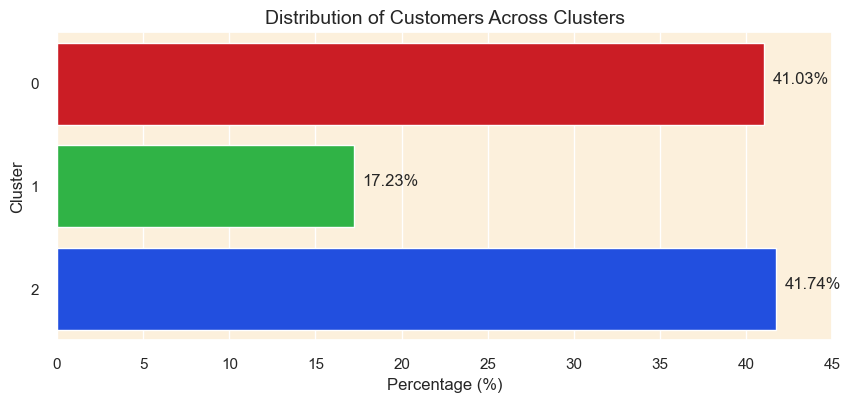

In [71]:
# Calculate the percentage of customers in each cluster
cluster_percentage = (customer_data_pca['cluster'].value_counts(normalize=True) * 100).reset_index()
cluster_percentage.columns = ['Cluster', 'Percentage']
cluster_percentage.sort_values(by='Cluster', inplace=True)
# Create a horizontal bar plot
plt.figure(figsize=(10, 4))
sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h', palette=colors)
# Adding percentages on the bars
for index, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value+0.5, index, f'{value:.2f}%')
plt.title('Distribution of Customers Across Clusters', fontsize=14)
plt.xticks(ticks=np.arange(0, 50, 5))
plt.xlabel('Percentage (%)')
# Show the plot
plt.show()

### Step10.3 : Evaluation Metrics

In [72]:
from tabulate import tabulate
# Compute number of customers
num_observations = len(customer_data_pca)
# Separate the features and the cluster labels
X = customer_data_pca.drop('cluster', axis=1)
clusters = customer_data_pca['cluster']
# Compute the metrics
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)
# Create a table to display the metrics and the number of observations
table_data = [
    ["Number of Observations", num_observations],
    ["Silhouette Score", sil_score],
    ["Calinski Harabasz Score", calinski_score],
    ["Davies Bouldin Score", davies_score]
]
# Print the table
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

+-------------------------+--------------------+
|         Metric          |       Value        |
+-------------------------+--------------------+
| Number of Observations  |        4075        |
|    Silhouette Score     | 0.2308680351184938 |
| Calinski Harabasz Score | 1227.5769905957345 |
|  Davies Bouldin Score   | 1.4084760337422437 |
+-------------------------+--------------------+


## Step11 : Cluster Analysis and Profiling

### Step11.1 : Histogram Chart Approach

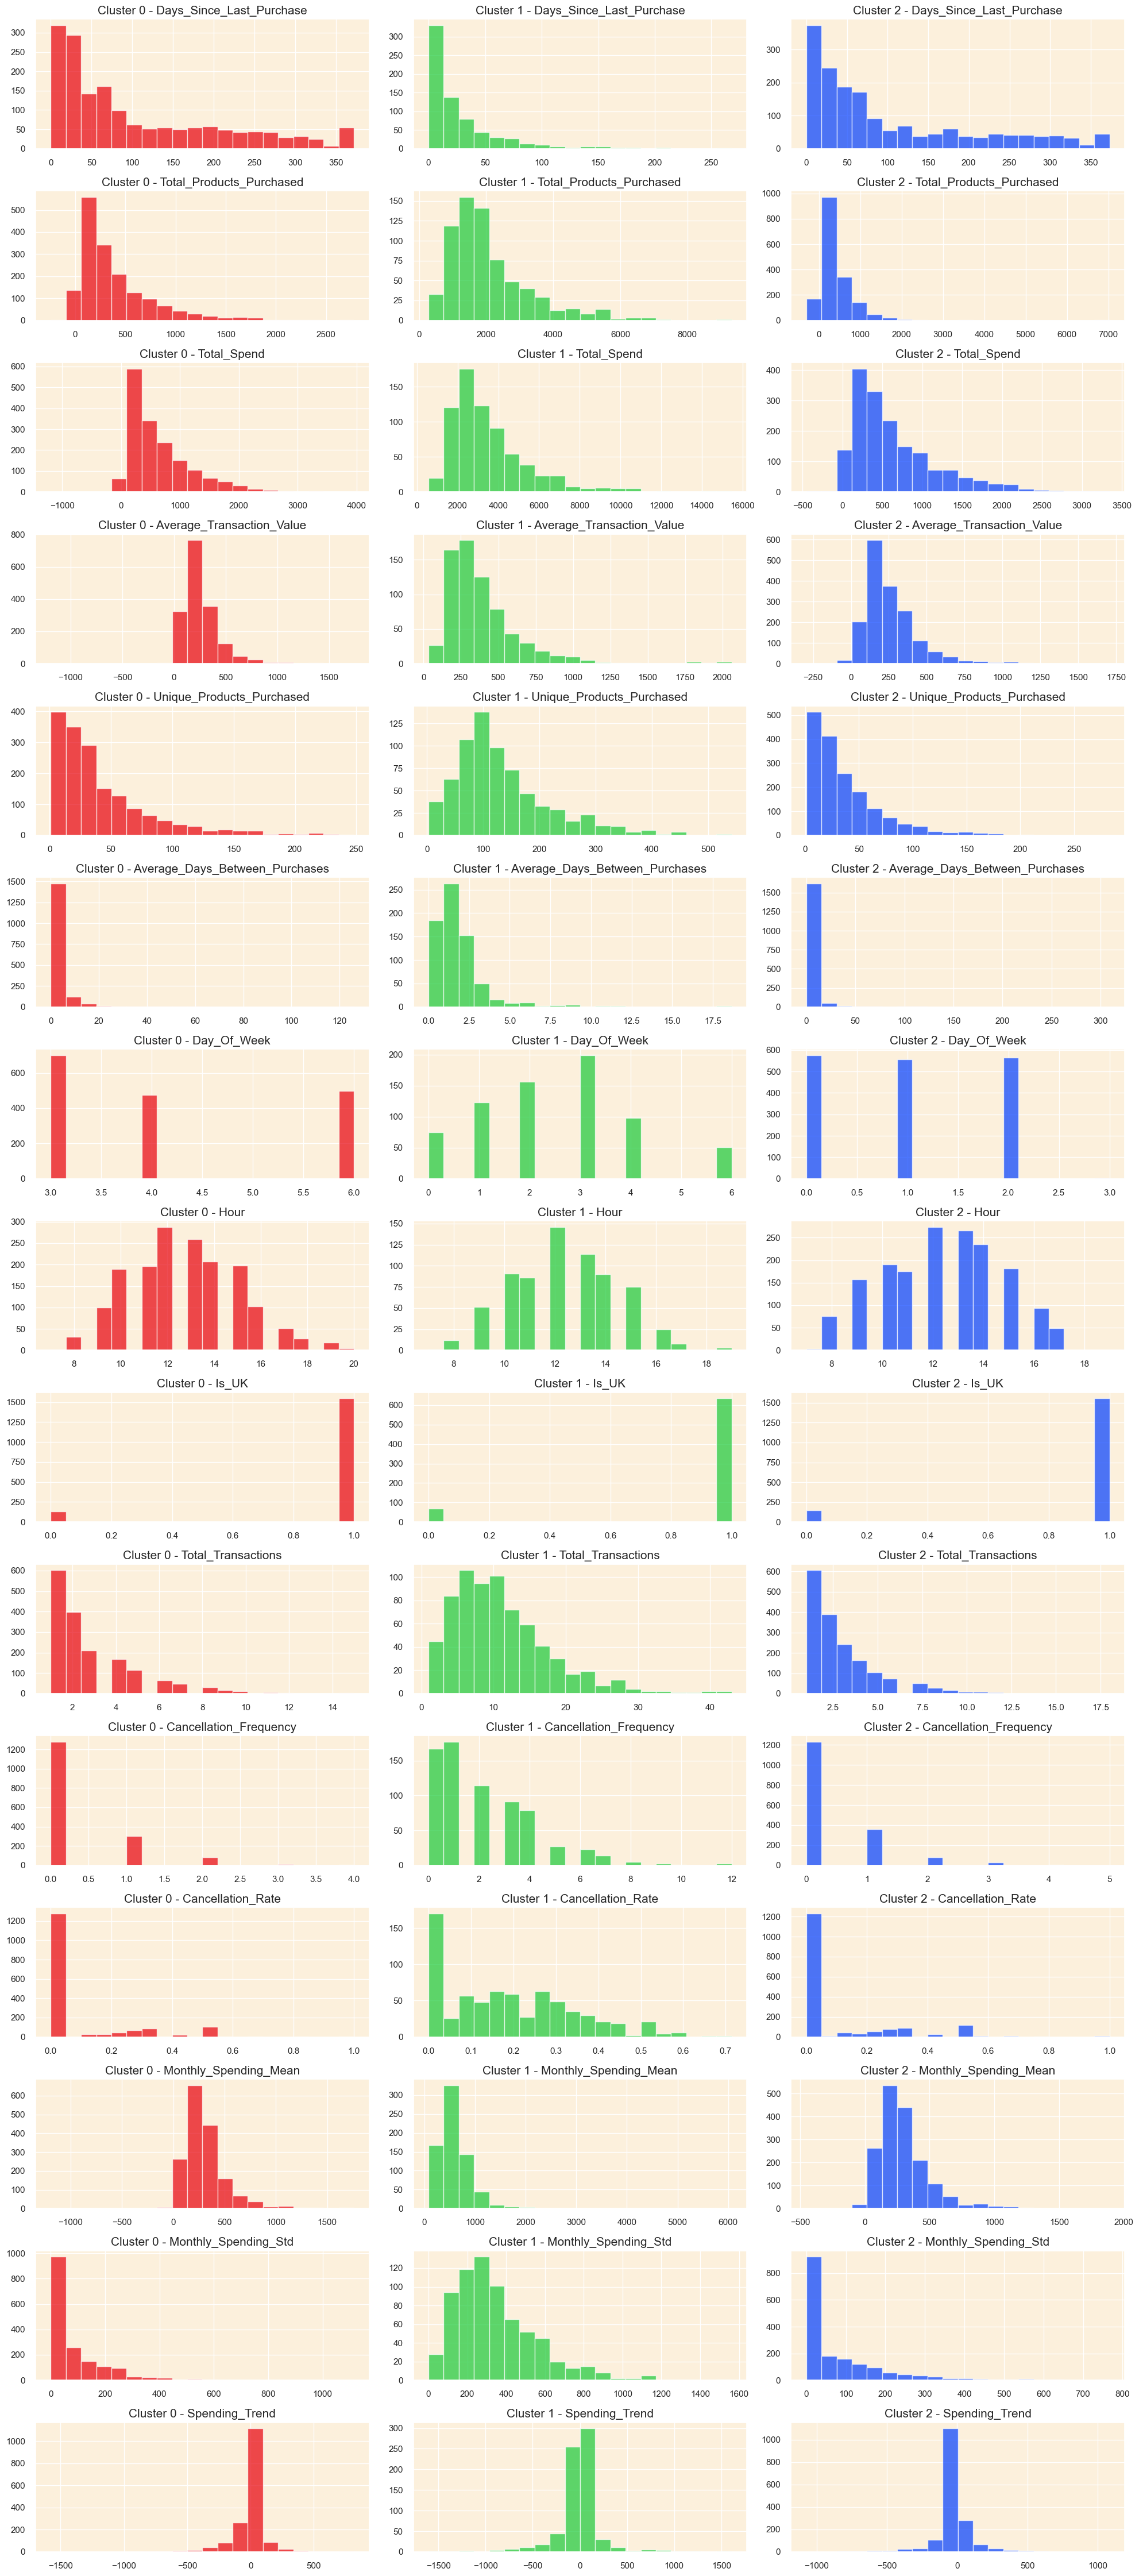

In [73]:
# Plot histograms for each feature segmented by the clusters
features = customer_data_cleaned.columns[1:-1]
clusters = customer_data_cleaned['cluster'].unique()
clusters.sort()
# Setting up the subplots
n_rows = len(features)
n_cols = len(clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))
# Plotting histograms
for i, feature in enumerate(features):
    for j, cluster in enumerate(clusters):
        data = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster][feature]
        axes[i, j].hist(data, bins=20, color=colors[j], edgecolor='w', alpha=0.7)
        axes[i, j].set_title(f'Cluster {cluster} - {feature}', fontsize=15)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')
# Adjusting layout to prevent overlapping
plt.tight_layout()
plt.show()

## Step12 : Recommendation System

In [74]:
# Modified Block to handle missing values in 'CustomerID' and 'Description' columns

# Step 1: Make sure CustomerID is the same dtype in both dataframes
dataset['CustomerID'] = dataset['CustomerID'].astype('float')
customer_data_cleaned['CustomerID'] = customer_data_cleaned['CustomerID'].astype('float')

# Step 2: Extract the CustomerIDs of the outliers and remove their transactions
outlier_customer_ids = outliers_data['CustomerID'].astype('float').unique()
dataset_filtered = dataset[~dataset['CustomerID'].isin(outlier_customer_ids)]

# Step 3: Merge transaction data with cluster labels
merged_data = dataset_filtered.merge(
    customer_data_cleaned[['CustomerID', 'cluster']],
    on='CustomerID',
    how='inner'
)

# Step 4: Best-selling products by cluster
best_selling_products = (
    merged_data.groupby(['cluster', 'StockCode', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(by=['cluster', 'Quantity'], ascending=[True, False])
)

top_products_per_cluster = best_selling_products.groupby('cluster').head(10)

# Step 5: Customer purchase history
customer_purchases = (
    merged_data.groupby(['CustomerID', 'cluster', 'StockCode'])['Quantity']
    .sum()
    .reset_index()
)

# Step 6: Generate recommendations
recommendations = []

for cluster in top_products_per_cluster['cluster'].unique():
    top_products = top_products_per_cluster[top_products_per_cluster['cluster'] == cluster]
    customers_in_cluster = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster]['CustomerID']

    for customer in customers_in_cluster:
        customer_purchased_products = customer_purchases[
            (customer_purchases['CustomerID'] == customer) &
            (customer_purchases['cluster'] == cluster)
        ]['StockCode'].tolist()

        top_products_not_purchased = top_products[~top_products['StockCode'].isin(customer_purchased_products)]
        top_3_products_not_purchased = top_products_not_purchased.head(3)

        rec_values = top_3_products_not_purchased[['StockCode', 'Description']].values.flatten().tolist()

        while len(rec_values) < 6:
            rec_values.extend([None, None])

        recommendations.append([customer, cluster] + rec_values[:6])

# Step 7: Final dataframe
recommendations_df = pd.DataFrame(
    recommendations,
    columns=[
        'CustomerID', 'cluster',
        'Rec1_StockCode', 'Rec1_Description',
        'Rec2_StockCode', 'Rec2_Description',
        'Rec3_StockCode', 'Rec3_Description'
    ]
)

customer_data_with_recommendations = customer_data_cleaned.merge(
    recommendations_df,
    on=['CustomerID', 'cluster'],
    how='right'
)

In [75]:
# Display 10 random rows from the customer_data_with_recommendations dataframe
customer_data_with_recommendations.set_index('CustomerID').iloc[:, -6:].sample(10, random_state=0)

,Rec1_StockCode,Rec1_Description,Rec2_StockCode,Rec2_Description,Rec3_StockCode,Rec3_Description
CustomerID,,,,,,
14798.0,84879,ASSORTED COLOUR BIRD ORNAMENT,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,17003,BROCADE RING PURSE
15958.0,84879,ASSORTED COLOUR BIRD ORNAMENT,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,17003,BROCADE RING PURSE
14234.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,15036,ASSORTED COLOURS SILK FAN,85123A,WHITE HANGING HEART T-LIGHT HOLDER
14334.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,85099B,JUMBO BAG RED RETROSPOT,84879,ASSORTED COLOUR BIRD ORNAMENT
17376.0,84879,ASSORTED COLOUR BIRD ORNAMENT,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,17003,BROCADE RING PURSE
17553.0,84879,ASSORTED COLOUR BIRD ORNAMENT,18007,ESSENTIAL BALM 3.5G TIN IN ENVELOPE,17003,BROCADE RING PURSE
15466.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT,15036,ASSORTED COLOURS SILK FAN
16108.0,84879,ASSORTED COLOUR BIRD ORNAMENT,15036,ASSORTED COLOURS SILK FAN,85123A,WHITE HANGING HEART T-LIGHT HOLDER
15723.0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879,ASSORTED COLOUR BIRD ORNAMENT,15036,ASSORTED COLOURS SILK FAN
